## NAME : PRAKASH K
### TASK 1 : PREDICTION USING SUPERVISED ML

#### PROBLEM STATEMENT : Predict the percentage of a student based on the no. of hours studied.

#### Importing the necessary library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Importing the dataset

In [3]:
file=pd.read_csv("http://bit.ly/w-data")

In [4]:
file

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


In [5]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
Hours     25 non-null float64
Scores    25 non-null int64
dtypes: float64(1), int64(1)
memory usage: 528.0 bytes


#### Plotting the graph

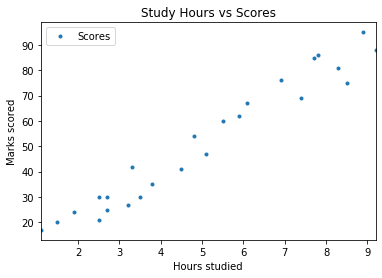

In [24]:
file.plot(x='Hours',y='Scores',style='.')
plt.title('Study Hours vs Scores')
plt.xlabel('Hours studied')
plt.ylabel('Marks scored')
plt.show()

In [81]:
X=file.drop('Scores',axis='columns')
Y=file.drop('Hours',axis='columns')

In [82]:
print(X.shape)



(25, 1)


#### Training the model

In [83]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=12)

In [84]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)


(20, 1)
(5, 1)
(20, 1)
(5, 1)


In [85]:
from sklearn.linear_model import LinearRegression 
lr= LinearRegression()

In [86]:
lr.fit(X_train,Y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [87]:
lr.coef_

array([[9.65531967]])

In [88]:
lr.intercept_

array([2.89069974])

In [89]:
line=lr.coef_*X + lr.intercept_
line

,Hours
0,27.028999
1,52.132830
2,33.787723
3,84.960917
4,36.684319
5,17.373679
6,91.719641
7,55.994958
8,83.029853
9,28.960063


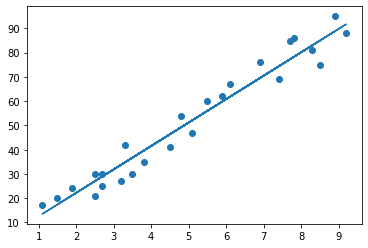

In [90]:
plt.scatter(X,Y)
plt.plot(X,line)
plt.show()

In [123]:
lr.predict([[9.25]])[0][0].round(1)

92.2

In [118]:
Y_pred=lr.predict(X_train)

In [98]:
Y_pred

array([[83.02985297],
       [36.68431857],
       [13.51155137],
       [39.58091447],
       [27.02899891],
       [77.23666117],
       [69.51240544],
       [78.20219314],
       [49.23623414],
       [28.96006284],
       [34.75325464],
       [17.37367924],
       [27.02899891],
       [46.33963824],
       [28.96006284],
       [84.9609169 ],
       [33.78772267],
       [21.23580711],
       [91.71964067],
       [59.85708577]])

In [105]:
pd.DataFrame(np.c_[X_train,Y_train,Y_pred], columns=["Hours","Scores_Original","Scores_Predicted"])

,Hours,Scores_Original,Scores_Predicted
0,8.3,81.0,83.029853
1,3.5,30.0,36.684319
2,1.1,17.0,13.511551
3,3.8,35.0,39.580914
4,2.5,21.0,27.028999
5,7.7,85.0,77.236661
6,6.9,76.0,69.512405
7,7.8,86.0,78.202193
8,4.8,54.0,49.236234
9,2.7,25.0,28.960063


In [111]:
lr.score(X_test,Y_test)

0.8897176466006437

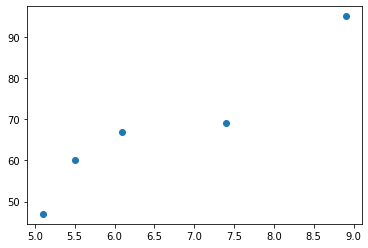

In [116]:
plt.scatter(X_test,Y_test)

In [119]:
import joblib

In [122]:
joblib.dump=(lr,"Student_marks_predictor.pkl")

### Q: What will be the predicted score if a student studies for 9.25hrs/day?

In [124]:
lr.predict([[9.25]])

array([[92.20240665]])

### A: If a student studied for 9.25hrs/day he will score 92.2%.